In [2]:
"""
=============================================================================
SPARSE AUTOENCODER FOR FEATURE REPRESENTATION — CIFAR-10
=============================================================================
A Sparse Autoencoder (SAE) is a neural network that:
  1. ENCODES  : Compresses input into a smaller hidden representation
  2. DECODES  : Reconstructs the original input from that representation
  3. SPARSITY : Forces most hidden neurons to be inactive (≈0) at any time
                This forces the network to learn meaningful, selective features

The sparsity constraint is enforced via KL Divergence penalty:
  KL(ρ || ρ̂) where ρ = target sparsity (e.g. 0.05) and ρ̂ = average activation

CIFAR-10 : 60,000 colour images, 32×32 pixels, 10 classes
Input dim : 32 × 32 × 3 = 3072 (flattened)
=============================================================================
"""

'\n=============================================================================\nSPARSE AUTOENCODER FOR FEATURE REPRESENTATION — CIFAR-10\n=============================================================================\nA Sparse Autoencoder (SAE) is a neural network that:\n  1. ENCODES  : Compresses input into a smaller hidden representation\n  2. DECODES  : Reconstructs the original input from that representation\n  3. SPARSITY : Forces most hidden neurons to be inactive (≈0) at any time\n                This forces the network to learn meaningful, selective features\n\nThe sparsity constraint is enforced via KL Divergence penalty:\n  KL(ρ || ρ̂) where ρ = target sparsity (e.g. 0.05) and ρ̂ = average activation\n\nCIFAR-10 : 60,000 colour images, 32×32 pixels, 10 classes\nInput dim : 32 × 32 × 3 = 3072 (flattened)\n=============================================================================\n'

In [3]:
# Run this once:
# pip install torch torchvision matplotlib numpy

import torch                              # Core PyTorch library
import torch.nn as nn                     # Neural network modules (Linear, ReLU etc.)
import torch.optim as optim               # Optimizers (Adam, SGD)
import torchvision                        # Dataset and transform utilities
import torchvision.transforms as transforms  # Image preprocessing pipeline
from torch.utils.data import DataLoader   # Batching and shuffling data

import numpy as np                        # Numerical operations
import matplotlib.pyplot as plt           # Plotting and visualization
import matplotlib.gridspec as gridspec    # Fine-grained subplot layout
from collections import defaultdict       # For storing per-experiment metrics

In [4]:
# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)                     # Fix PyTorch random seed
np.random.seed(42)                        # Fix NumPy random seed

# ── Device setup ─────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
# If DEVICE prints 'cuda' → GPU training (fast)
# If DEVICE prints 'cpu'  → CPU training (slower but works)

Using device: cuda


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # Converts PIL Image (H×W×C, uint8 0-255) to Tensor (C×H×W, float32 0-1)
    # Shape: (3, 32, 32)

    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),   # CIFAR-10 channel means (precomputed)
        std =(0.2470, 0.2435, 0.2616)    # CIFAR-10 channel std devs
    )
    # Normalizes each channel: pixel = (pixel - mean) / std
    # Zero-centers the data → helps gradient flow and faster convergence
])

In [6]:
# ── Download datasets ─────────────────────────────────────────────────────────
train_dataset = torchvision.datasets.CIFAR10(
    root      = "./data",      # Where to save the downloaded data
    train     = True,          # Load training split (50,000 images)
    download  = True,          # Download if not already present
    transform = transform      # Apply the preprocessing pipeline above
)

test_dataset = torchvision.datasets.CIFAR10(
    root      = "./data",
    train     = False,         # Load test split (10,000 images)
    download  = True,
    transform = transform
)

100%|██████████| 170M/170M [00:05<00:00, 29.6MB/s]


In [7]:
# ── Create DataLoaders ────────────────────────────────────────────────────────
BATCH_SIZE = 128              # Number of images per training step

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,        # Randomize order each epoch — prevents pattern memorization
    num_workers = 2,           # Parallel CPU workers for loading data
    pin_memory  = True         # Faster CPU→GPU transfer
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,       # No need to shuffle test data
    num_workers = 2,
    pin_memory  = True
)

print(f"Training samples : {len(train_dataset)}")  # 50,000
print(f"Test samples     : {len(test_dataset)}")   # 10,000
print(f"Batches per epoch: {len(train_loader)}")   # 50000 / 128 ≈ 391

# Class names for visualization
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']



Training samples : 50000
Test samples     : 10000
Batches per epoch: 391


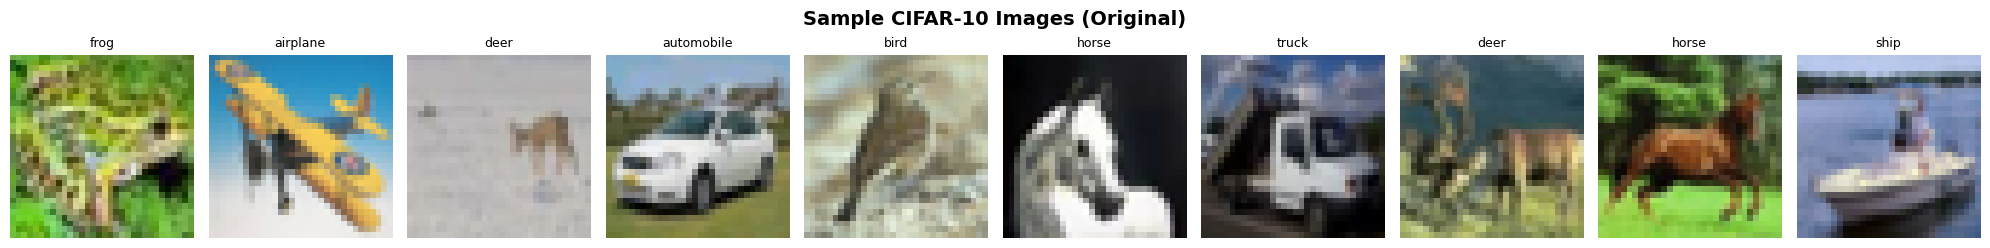

[Saved] cifar10_samples.png


In [8]:
# CELL 3 — VISUALIZE RAW CIFAR-10 SAMPLES
# =============================================================================

def denormalize(tensor):
    """
    Reverse the normalization to display images correctly.
    Without this, images look washed out or have wrong colours.
    """
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)  # Shape: (3,1,1) for broadcasting
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)   # clamp keeps values in valid [0,1] range

def show_cifar_samples(loader, n=10):
    """Display n raw CIFAR-10 images with their class labels."""
    imgs, labels = next(iter(loader))   # Get first batch
    imgs = imgs[:n]                      # Take first n images

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    fig.suptitle("Sample CIFAR-10 Images (Original)", fontsize=14, fontweight='bold')

    for i, (ax, img, lbl) in enumerate(zip(axes, imgs, labels)):
        img_display = denormalize(img)               # Undo normalization
        ax.imshow(img_display.permute(1,2,0).numpy()) # (C,H,W) → (H,W,C) for matplotlib
        ax.set_title(CLASSES[lbl], fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("cifar10_samples.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] cifar10_samples.png")

show_cifar_samples(train_loader)


In [9]:
# CELL 4 — SPARSE AUTOENCODER ARCHITECTURE
# =============================================================================
"""
ARCHITECTURE DIAGRAM
────────────────────
Input (3072)          ← Flattened 32×32×3 image
    │
    ▼ Encoder
  Linear(3072 → 1024) → ReLU     ← First compression layer
  Linear(1024 → 512)  → ReLU     ← Second compression layer
  Linear(512  → 256)  → Sigmoid  ← Bottleneck (latent code) — Sigmoid keeps values [0,1]
    │
    │  ← SPARSITY enforced here via KL Divergence
    │
    ▼ Decoder
  Linear(256  → 512)  → ReLU     ← First expansion layer
  Linear(512  → 1024) → ReLU     ← Second expansion layer
  Linear(1024 → 3072) → Sigmoid  ← Reconstruction (output same size as input)
    │
    ▼
Output (3072)         ← Reconstructed image (flatten)

KEY: Sigmoid at bottleneck keeps activations in [0,1] making KL-divergence meaningful
"""



'\nARCHITECTURE DIAGRAM\n────────────────────\nInput (3072)          ← Flattened 32×32×3 image\n    │\n    ▼ Encoder\n  Linear(3072 → 1024) → ReLU     ← First compression layer\n  Linear(1024 → 512)  → ReLU     ← Second compression layer\n  Linear(512  → 256)  → Sigmoid  ← Bottleneck (latent code) — Sigmoid keeps values [0,1]\n    │\n    │  ← SPARSITY enforced here via KL Divergence\n    │\n    ▼ Decoder\n  Linear(256  → 512)  → ReLU     ← First expansion layer\n  Linear(512  → 1024) → ReLU     ← Second expansion layer\n  Linear(1024 → 3072) → Sigmoid  ← Reconstruction (output same size as input)\n    │\n    ▼\nOutput (3072)         ← Reconstructed image (flatten)\n\nKEY: Sigmoid at bottleneck keeps activations in [0,1] making KL-divergence meaningful\n'

In [10]:
class SparseAutoencoder(nn.Module):
    """
    Sparse Autoencoder with 3-layer encoder and 3-layer decoder.
    Sparsity is enforced by penalizing the average hidden activation.
    """

    def __init__(self,
                 input_dim   : int   = 3072,   # 32×32×3 = 3072 for CIFAR-10
                 hidden_dim1 : int   = 1024,   # First encoder layer size
                 hidden_dim2 : int   = 512,    # Second encoder layer size
                 latent_dim  : int   = 256,    # Bottleneck (code) dimension
                 sparsity_target : float = 0.05,  # ρ — desired average activation
                 sparsity_weight : float = 1e-3   # β — how strongly to enforce sparsity
                 ):
        super(SparseAutoencoder, self).__init__()
        # super().__init__() calls nn.Module's constructor — required for PyTorch bookkeeping

        # ── Store hyperparameters ─────────────────────────────────────────────
        self.sparsity_target = sparsity_target   # ρ (rho) — target neuron activation
        self.sparsity_weight = sparsity_weight   # β (beta) — sparsity loss weight
        self.latent_dim      = latent_dim

        # ── ENCODER ──────────────────────────────────────────────────────────
        # The encoder compresses the 3072-dim input into a 256-dim latent code
        self.encoder = nn.Sequential(
            nn.Linear(input_dim,   hidden_dim1),  # 3072 → 1024: weight matrix 3072×1024
            nn.ReLU(inplace=True),                # ReLU: f(x) = max(0,x) — keeps positive activations
            nn.BatchNorm1d(hidden_dim1),           # Normalize activations for stable training

            nn.Linear(hidden_dim1, hidden_dim2),  # 1024 → 512
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim2),

            nn.Linear(hidden_dim2, latent_dim),   # 512 → 256 (bottleneck)
            nn.Sigmoid()                          # Sigmoid: output in [0,1] — required for KL sparsity
            # Sigmoid because KL divergence formula treats activations as probabilities
        )

        # ── DECODER ──────────────────────────────────────────────────────────
        # The decoder reconstructs the 3072-dim image from the 256-dim code
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,  hidden_dim2),  # 256 → 512: mirror of encoder
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim2),

            nn.Linear(hidden_dim2, hidden_dim1),  # 512 → 1024
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim1),

            nn.Linear(hidden_dim1, input_dim),    # 1024 → 3072: full reconstruction
            nn.Sigmoid()                          # Output in [0,1] to match normalized input range
        )

    def forward(self, x):
        """
        Forward pass: encode input, then decode back to input space.
        x shape: (batch_size, 3072)
        """
        latent      = self.encoder(x)    # Compress: (B, 3072) → (B, 256)
        reconstructed = self.decoder(latent)   # Expand:   (B, 256) → (B, 3072)
        return reconstructed, latent     # Return both for computing losses

    def kl_divergence(self, rho_hat):
        """
        KL Divergence sparsity penalty.

        This measures how different the actual average activation (rho_hat)
        is from the target sparsity (rho = self.sparsity_target).

        Formula: KL(ρ || ρ̂) = ρ·log(ρ/ρ̂) + (1-ρ)·log((1-ρ)/(1-ρ̂))

        When ρ̂ ≈ ρ → KL ≈ 0 (no penalty)
        When ρ̂ >> ρ → KL is large (neurons too active → penalized)

        rho_hat: average activation of each hidden neuron across the batch
                 shape: (latent_dim,) — one value per neuron
        """
        rho     = self.sparsity_target                 # Target: e.g. 0.05
        rho_hat = torch.clamp(rho_hat, 1e-6, 1-1e-6)  # Prevent log(0) which is -infinity

        # KL divergence formula
        kl = rho * torch.log(rho / rho_hat) \
           + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

        return kl.sum()   # Sum over all latent neurons


In [11]:
# ── Print architecture ────────────────────────────────────────────────────────
model = SparseAutoencoder(
    input_dim        = 3072,   # CIFAR-10: 32×32×3
    hidden_dim1      = 1024,
    hidden_dim2      = 512,
    latent_dim       = 256,
    sparsity_target  = 0.05,   # We want only 5% of neurons active on average
    sparsity_weight  = 1e-3    # β: how much weight to give sparsity vs reconstruction
).to(DEVICE)

print("\n=== Sparse Autoencoder Architecture ===")
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")
# ~3.4 million parameters — most are in the first linear layer (3072×1024)




=== Sparse Autoencoder Architecture ===
SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU(inplace=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU(inplace=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=1024, out_features=3072, bias=True)
    (7): Sigmoi

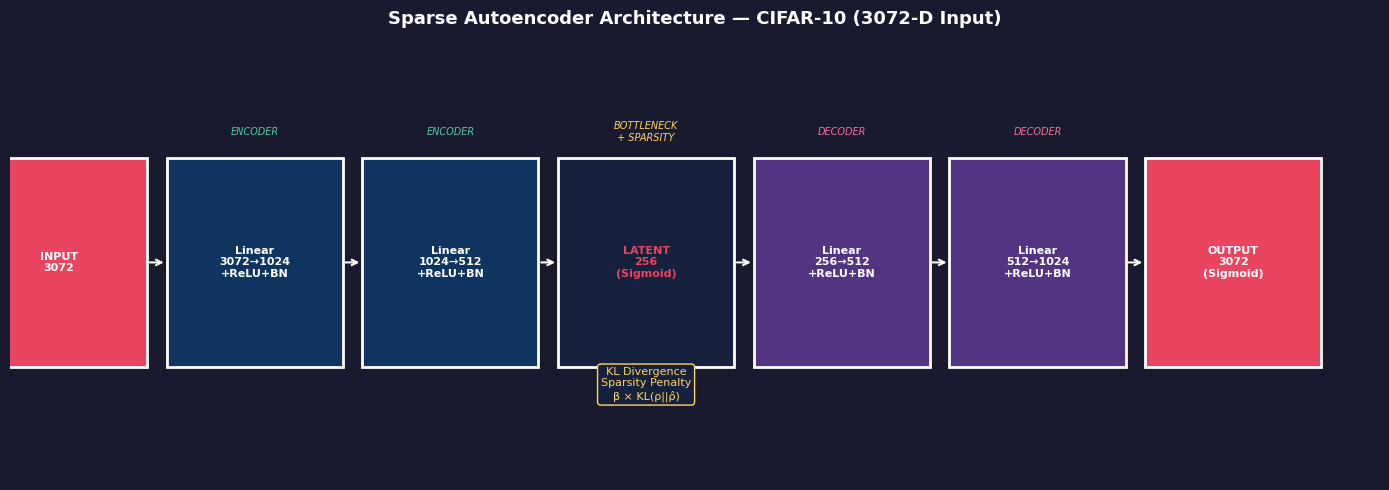

[Saved] sae_architecture.png


In [12]:
# CELL 5 — VISUALIZE ARCHITECTURE AS DIAGRAM


def plot_architecture():
    """Draw the SAE architecture as a visual block diagram."""
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis('off')
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')

    layers = [
        (0.5,  2.5, "INPUT\n3072", '#e94560',   'white'),
        (2.5,  2.5, "Linear\n3072→1024\n+ReLU+BN", '#0f3460','white'),
        (4.5,  2.5, "Linear\n1024→512\n+ReLU+BN",  '#0f3460','white'),
        (6.5,  2.5, "LATENT\n256\n(Sigmoid)", '#16213e','#e94560'),
        (8.5,  2.5, "Linear\n256→512\n+ReLU+BN",   '#533483','white'),
        (10.5, 2.5, "Linear\n512→1024\n+ReLU+BN",  '#533483','white'),
        (12.5, 2.5, "OUTPUT\n3072\n(Sigmoid)", '#e94560','white'),
    ]

    labels = ["", "ENCODER", "ENCODER", "BOTTLENECK\n+ SPARSITY", "DECODER", "DECODER", ""]
    colors_lbl = ['','#4ecca3','#4ecca3','#ffd460','#ff6b9d','#ff6b9d','']

    for i, (x, y, text, color, tcolor) in enumerate(layers):
        # Draw box
        rect = plt.Rectangle((x-0.9, y-1.2), 1.8, 2.4,
                               facecolor=color, edgecolor='white',
                               linewidth=2, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, ha='center', va='center',
                color=tcolor, fontsize=8, fontweight='bold', zorder=4)
        # Label above
        if labels[i]:
            ax.text(x, y+1.5, labels[i], ha='center', va='center',
                    color=colors_lbl[i], fontsize=7, style='italic')

        # Draw arrows between boxes
        if i < len(layers)-1:
            ax.annotate("", xy=(layers[i+1][0]-0.9, y),
                           xytext=(x+0.9, y),
                           arrowprops=dict(arrowstyle="->", color='white', lw=1.5))

    # Add KL divergence annotation
    ax.annotate("KL Divergence\nSparsity Penalty\nβ × KL(ρ||ρ̂)",
                xy=(6.5, 1.3), ha='center', va='top',
                color='#ffd460', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#16213e', edgecolor='#ffd460'))
    ax.annotate("", xy=(6.5, 1.3), xytext=(6.5, 1.3),
                arrowprops=dict(arrowstyle="->", color='#ffd460'))

    ax.set_title("Sparse Autoencoder Architecture — CIFAR-10 (3072-D Input)",
                 color='white', fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig("sae_architecture.png", dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()
    print("[Saved] sae_architecture.png")

plot_architecture()

In [13]:
# CELL 6 — LOSS FUNCTION & TRAINING LOOP
# =============================================================================

def compute_loss(model, x_flat, reconstructed, latent):
    """
    Total SAE loss = Reconstruction Loss + β × Sparsity Loss

    1. Reconstruction Loss (MSE):
       Measures how well the decoder rebuilt the original image.
       MSE = (1/N) × Σ(x - x̂)²
       Lower MSE → better reconstruction

    2. Sparsity Loss (KL Divergence):
       Penalizes neurons that are too active.
       rho_hat = mean activation of each latent neuron across the batch
       KL(ρ || ρ̂) → 0 when average activation ≈ target sparsity ρ

    3. Total Loss:
       L = MSE + β × KL
       β controls the trade-off: high β → more sparse, potentially worse reconstruction
    """
    # Reconstruction loss — how different is output from input?
    recon_loss = nn.MSELoss()(reconstructed, x_flat)
    # MSELoss computes mean squared error over all pixels and batch samples

    # Average activation of each latent neuron across the batch
    rho_hat = latent.mean(dim=0)
    # dim=0 averages over the batch dimension → shape: (latent_dim,)
    # Each value = average activation of one hidden neuron

    # Sparsity penalty
    sparsity_loss = model.kl_divergence(rho_hat)

    # Total loss: reconstruction + weighted sparsity
    total_loss = recon_loss + model.sparsity_weight * sparsity_loss

    return total_loss, recon_loss.item(), sparsity_loss.item()


def train_epoch(model, loader, optimizer):
    """Run one full pass through the training data."""
    model.train()                    # Enable dropout/batchnorm training mode
    total_loss = recon_sum = sparse_sum = 0.0
    n_batches  = 0

    for imgs, _ in loader:
        # imgs shape: (batch_size, 3, 32, 32)
        # _ = labels (unused — autoencoders are unsupervised)

        imgs = imgs.to(DEVICE)       # Move to GPU if available

        # Flatten: (B, 3, 32, 32) → (B, 3072)
        x_flat = imgs.view(imgs.size(0), -1)
        # .view() reshapes without copying data
        # imgs.size(0) = batch size, -1 = infer remaining dim (3×32×32=3072)

        # --- Forward pass ---
        reconstructed, latent = model(x_flat)   # Get reconstruction and hidden code

        # --- Compute loss ---
        loss, rl, sl = compute_loss(model, x_flat, reconstructed, latent)

        # --- Backward pass ---
        optimizer.zero_grad()    # Clear gradients from previous batch
        loss.backward()          # Compute gradients via backpropagation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Gradient clipping: prevents exploding gradients by capping gradient norm at 1.0
        optimizer.step()         # Update weights: w = w - lr × gradient

        total_loss += loss.item()    # .item() converts 1-element tensor to Python float
        recon_sum  += rl
        sparse_sum += sl
        n_batches  += 1

    # Return average losses per batch
    return total_loss/n_batches, recon_sum/n_batches, sparse_sum/n_batches


def evaluate_epoch(model, loader):
    """Evaluate model on test data without updating weights."""
    model.eval()                     # Disable dropout/batchnorm training mode
    total_loss = recon_sum = 0.0
    n_batches  = 0

    with torch.no_grad():
        # torch.no_grad(): disable gradient tracking — saves memory, speeds up inference
        for imgs, _ in loader:
            imgs   = imgs.to(DEVICE)
            x_flat = imgs.view(imgs.size(0), -1)
            reconstructed, latent = model(x_flat)
            loss, rl, _ = compute_loss(model, x_flat, reconstructed, latent)
            total_loss += loss.item()
            recon_sum  += rl
            n_batches  += 1

    return total_loss/n_batches, recon_sum/n_batches


In [14]:
EPOCHS = 30          # Number of full passes through the training data
LR     = 1e-3        # Learning rate — step size for gradient descent

optimizer = optim.Adam(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-5   # L2 regularization — prevents weights from growing too large
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',    # Reduce LR when loss stops decreasing
    factor   = 0.5,      # Multiply LR by 0.5 when triggered
    patience = 3,        # Wait 3 epochs before reducing
    #verbose  = True      # Print a message when LR is reduced
)

# Storage for plotting training curves
history = {
    'train_loss': [], 'val_loss': [],
    'train_recon': [], 'val_recon': [],
    'train_sparse': []
}

best_val_loss = float('inf')    # Track best model for saving
print("\n=== Training Sparse Autoencoder ===")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Recon':>8} | {'Sparse':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    # Training pass
    tr_loss, tr_recon, tr_sparse = train_epoch(model, train_loader, optimizer)

    # Validation pass
    vl_loss, vl_recon = evaluate_epoch(model, test_loader)

    # Adjust LR if plateau
    scheduler.step(vl_loss)

    # Store metrics
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_recon'].append(tr_recon)
    history['val_recon'].append(vl_recon)
    history['train_sparse'].append(tr_sparse)

    # Save best model
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), "best_sae.pth")  # Save only weights


    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}| Curr_LR {current_lr}| {tr_loss:>10.4f} | {vl_loss:>10.4f} | {tr_recon:>8.4f} | {tr_sparse:>8.4f}")

print(f"\nBest Val Loss: {best_val_loss:.4f}")
print("[Saved] best_sae.pth")



=== Training Sparse Autoencoder ===
 Epoch | Train Loss |   Val Loss |    Recon |   Sparse
-------------------------------------------------------
Epoch 1| Curr_LR 0.001|     0.7400 |     0.6627 |   0.7057 |  34.2978
Epoch 2| Curr_LR 0.001|     0.6621 |     0.6414 |   0.6618 |   0.3199
Epoch 3| Curr_LR 0.001|     0.6452 |     0.6313 |   0.6451 |   0.1355
Epoch 4| Curr_LR 0.001|     0.6368 |     0.6236 |   0.6367 |   0.1029
Epoch 5| Curr_LR 0.001|     0.6308 |     0.6198 |   0.6307 |   0.0816
Epoch 6| Curr_LR 0.001|     0.6259 |     0.6137 |   0.6259 |   0.0728
Epoch 7| Curr_LR 0.001|     0.6218 |     0.6108 |   0.6218 |   0.0603
Epoch 8| Curr_LR 0.001|     0.6197 |     0.6101 |   0.6196 |   0.0514
Epoch 9| Curr_LR 0.001|     0.6177 |     0.6093 |   0.6176 |   0.0454
Epoch 10| Curr_LR 0.001|     0.6166 |     0.6085 |   0.6165 |   0.0405
Epoch 11| Curr_LR 0.001|     0.6158 |     0.6071 |   0.6157 |   0.0372
Epoch 12| Curr_LR 0.001|     0.6147 |     0.6054 |   0.6147 |   0.0335
Epoch 13|

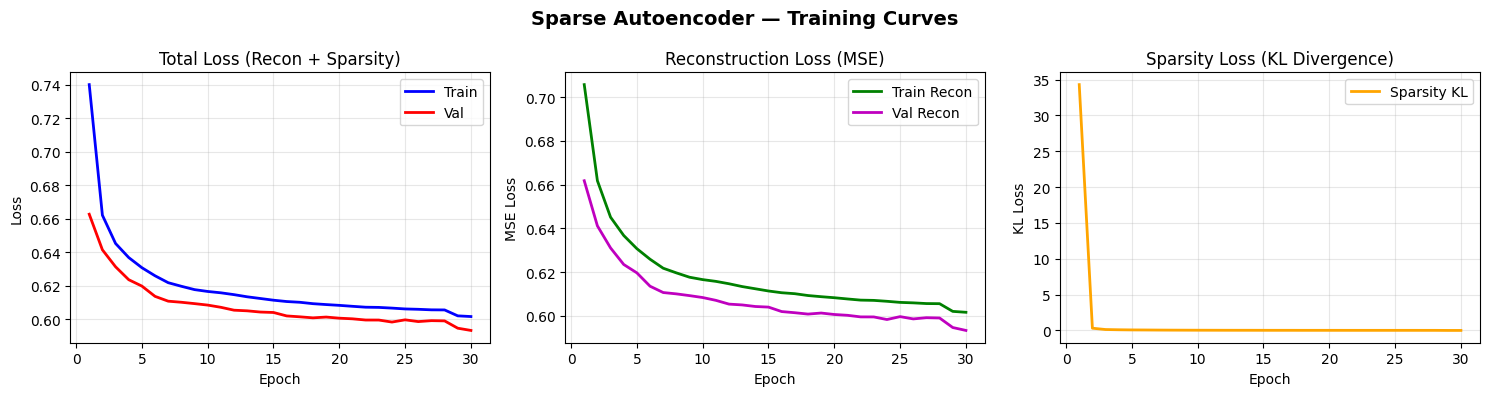

[Saved] training_curves_sae.png


In [15]:
# CELL 8 — PLOT TRAINING CURVES
# =============================================================================

def plot_training_curves(history):
    """Plot loss curves to analyze training behaviour."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Sparse Autoencoder — Training Curves", fontsize=14, fontweight='bold')

    # Plot 1: Total Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs, history['val_loss'],   'r-', label='Val',   linewidth=2)
    axes[0].set_title("Total Loss (Recon + Sparsity)")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    # If val loss >> train loss → overfitting
    # If both decrease smoothly → healthy training

    # Plot 2: Reconstruction Loss Only
    axes[1].plot(epochs, history['train_recon'], 'g-', label='Train Recon', linewidth=2)
    axes[1].plot(epochs, history['val_recon'],   'm-', label='Val Recon',   linewidth=2)
    axes[1].set_title("Reconstruction Loss (MSE)")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE Loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Plot 3: Sparsity Loss
    axes[2].plot(epochs, history['train_sparse'], 'orange', label='Sparsity KL', linewidth=2)
    axes[2].set_title("Sparsity Loss (KL Divergence)")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("KL Loss")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    # Should decrease as neurons learn to match the target sparsity ρ

    plt.tight_layout()
    plt.savefig("training_curves_sae.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] training_curves_sae.png")

plot_training_curves(history)

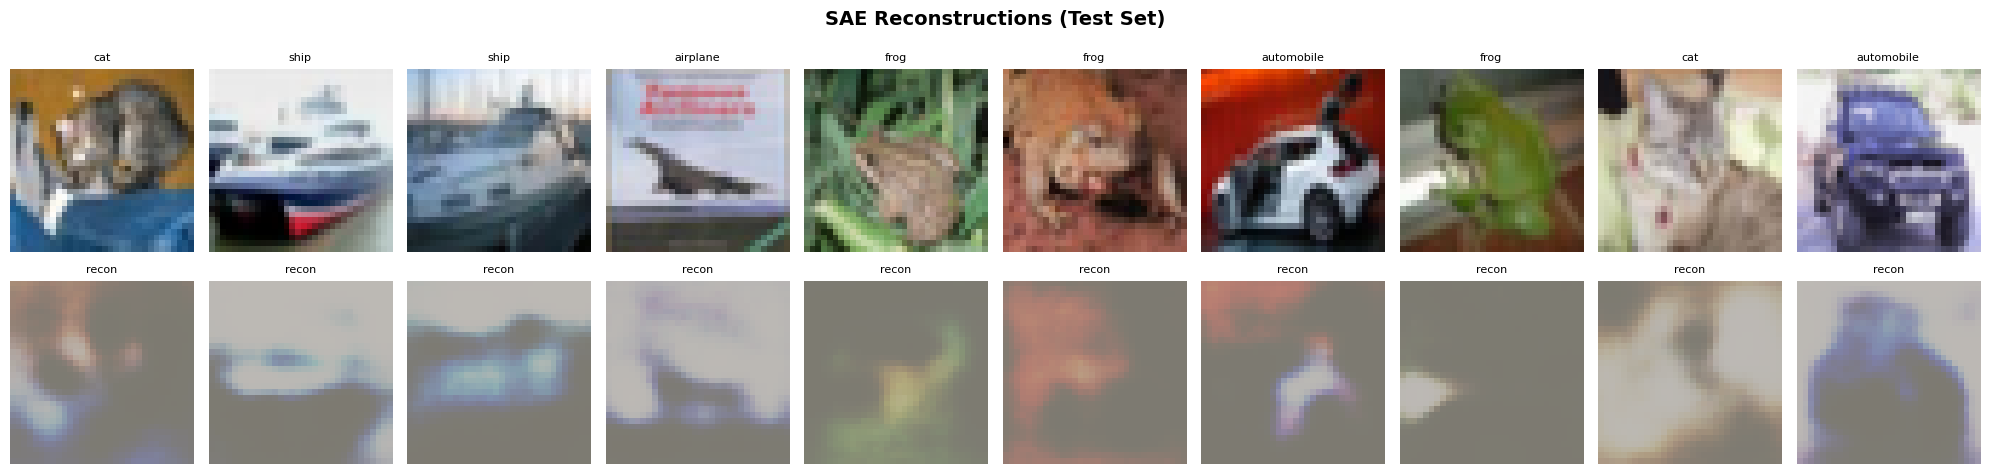

[Saved] sae_reconstructions_(test_set).png


In [16]:
# CELL 9 — VISUALIZE ORIGINAL vs RECONSTRUCTED IMAGES
# =============================================================================

def visualize_reconstructions(model, loader, n=10, title="SAE Reconstructions"):
    """
    Show original images on top row and their reconstructions on bottom row.
    The closer the rows look, the better the autoencoder is working.
    """
    model.eval()
    imgs, labels = next(iter(loader))   # Get one batch
    imgs = imgs[:n].to(DEVICE)          # Take first n images

    with torch.no_grad():
        x_flat = imgs.view(imgs.size(0), -1)           # Flatten for model
        reconstructed, latent = model(x_flat)           # Get reconstructions
        reconstructed = reconstructed.view(imgs.size(0), 3, 32, 32)  # Reshape back to images

    fig, axes = plt.subplots(2, n, figsize=(2*n, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i in range(n):
        # ── Row 1: Original images ────────────────────────────────────────────
        orig = denormalize(imgs[i].cpu())              # Undo normalization
        axes[0, i].imshow(orig.permute(1,2,0).numpy()) # (C,H,W) → (H,W,C)
        axes[0, i].set_title(CLASSES[labels[i]], fontsize=8)
        axes[0, i].axis("off")

        # ── Row 2: Reconstructed images ───────────────────────────────────────
        # Note: reconstructions are in [0,1] via Sigmoid, but were trained on
        # normalized input, so we denormalize for fair visual comparison
        recon = reconstructed[i].cpu()
        recon_display = denormalize(recon)             # Undo normalization
        axes[1, i].imshow(recon_display.permute(1,2,0).numpy())
        axes[1, i].set_title("recon", fontsize=8)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original",     fontsize=11, rotation=0, labelpad=50)
    axes[1, 0].set_ylabel("Reconstructed",fontsize=11, rotation=0, labelpad=50)

    plt.tight_layout()
    fname = title.replace(" ", "_").lower() + ".png"
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"[Saved] {fname}")

# Load best weights and visualize
model.load_state_dict(torch.load("best_sae.pth", map_location=DEVICE, weights_only=False))
visualize_reconstructions(model, test_loader, n=10, title="SAE Reconstructions (Test Set)")



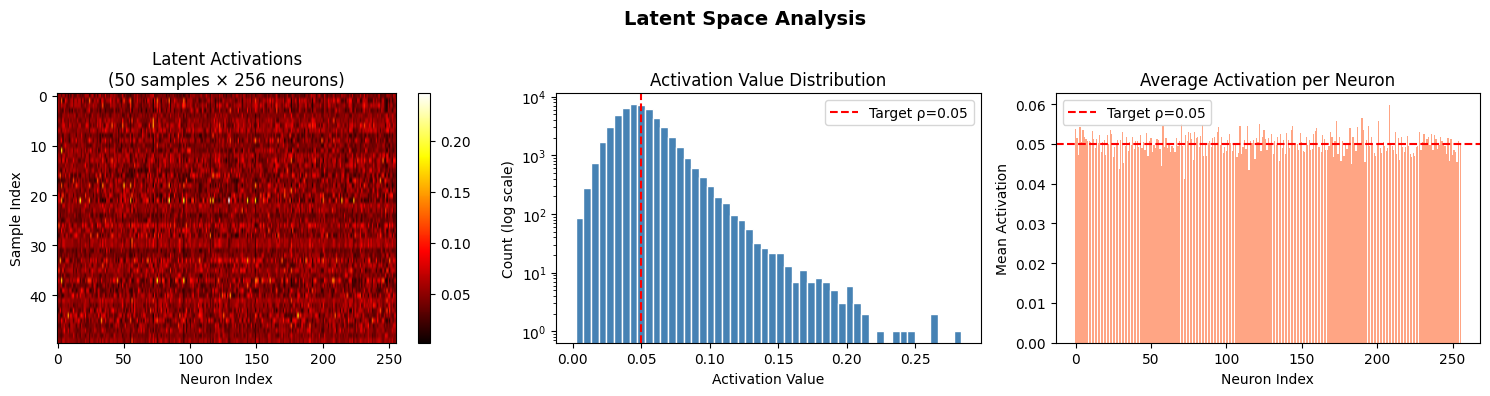

[Saved] latent_analysis.png

Sparsity Statistics:
  Target sparsity  (ρ)    : 0.050
  Actual mean activation  : 0.0502
  Fraction < 0.1 (sparse) : 98.2%


In [17]:
# CELL 10 — VISUALIZE LATENT SPACE ACTIVATIONS
# =============================================================================

def visualize_latent_activations(model, loader, n_images=200):
    """
    Show what the latent (hidden) layer activations look like.
    For a good sparse autoencoder, most neurons should be near 0 (dark)
    with only a few brightly activated.
    """
    model.eval()
    all_latents = []

    with torch.no_grad():
        for imgs, _ in loader:
            imgs   = imgs.to(DEVICE)
            x_flat = imgs.view(imgs.size(0), -1)
            _, latent = model(x_flat)              # Get latent codes
            all_latents.append(latent.cpu())
            if len(all_latents) * imgs.size(0) >= n_images:
                break

    all_latents = torch.cat(all_latents, dim=0)[:n_images]
    # Shape: (n_images, latent_dim) = (200, 256)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Latent Space Analysis", fontsize=14, fontweight='bold')

    # ── Plot 1: Activation heatmap (first 50 images, all 256 neurons) ─────────
    axes[0].imshow(all_latents[:50].numpy(), aspect='auto', cmap='hot')
    # 'hot' colormap: dark = inactive (near 0), bright = active (near 1)
    axes[0].set_title("Latent Activations\n(50 samples × 256 neurons)")
    axes[0].set_xlabel("Neuron Index"); axes[0].set_ylabel("Sample Index")
    plt.colorbar(axes[0].images[0], ax=axes[0])
    # Most should be dark → sparse!

    # ── Plot 2: Histogram of all activation values ────────────────────────────
    axes[1].hist(all_latents.numpy().flatten(), bins=50,
                 color='steelblue', edgecolor='white', log=True)
    # log=True: log scale on y-axis — highlights the spike near 0
    axes[1].set_title("Activation Value Distribution")
    axes[1].set_xlabel("Activation Value"); axes[1].set_ylabel("Count (log scale)")
    axes[1].axvline(x=model.sparsity_target, color='red', linestyle='--',
                    label=f'Target ρ={model.sparsity_target}')
    axes[1].legend()
    # Good sparsity: huge spike near 0, long tail toward 1

    # ── Plot 3: Average activation per neuron ─────────────────────────────────
    avg_activation = all_latents.mean(dim=0).numpy()   # Shape: (256,)
    axes[2].bar(range(len(avg_activation)), avg_activation, color='coral', alpha=0.7)
    axes[2].axhline(y=model.sparsity_target, color='red', linestyle='--',
                    label=f'Target ρ={model.sparsity_target}')
    axes[2].set_title("Average Activation per Neuron")
    axes[2].set_xlabel("Neuron Index"); axes[2].set_ylabel("Mean Activation")
    axes[2].legend()
    # Good sparsity: most bars near 0, close to the red dashed line

    plt.tight_layout()
    plt.savefig("latent_analysis.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] latent_analysis.png")

    # Print sparsity statistics
    mean_act = all_latents.mean().item()
    frac_near_zero = (all_latents < 0.1).float().mean().item()
    print(f"\nSparsity Statistics:")
    print(f"  Target sparsity  (ρ)    : {model.sparsity_target:.3f}")
    print(f"  Actual mean activation  : {mean_act:.4f}")
    print(f"  Fraction < 0.1 (sparse) : {frac_near_zero*100:.1f}%")

visualize_latent_activations(model, test_loader)


In [18]:
# CELL 11 — EXPERIMENT: DIFFERENT SPARSITY VALUES
# =============================================================================
"""
KEY EXPERIMENT: How does the sparsity weight β affect reconstruction?

β too LOW  → almost no sparsity constraint → model behaves like normal autoencoder
              neurons can activate freely → good reconstruction, no sparse features

β too HIGH → strong sparsity → most neurons forced to 0 → poor reconstruction
              the model can't represent enough information

Goal: Find the sweet spot β where reconstruction is decent AND features are sparse
"""

SPARSITY_VALUES = [0.0, 1e-4, 1e-3, 5e-3, 1e-2]
# β = 0.0  → no sparsity penalty (baseline)
# β = 1e-4 → very mild sparsity
# β = 1e-3 → moderate (default above)
# β = 5e-3 → stronger
# β = 1e-2 → aggressive

experiment_results = {}   # Store results for comparison
EXPERIMENT_EPOCHS = 15    # Fewer epochs for quick comparison

print("\n=== Sparsity Experiment ===")
print(f"{'β (weight)':>12} | {'Val Recon Loss':>15} | {'Mean Activation':>16} | {'Sparsity %':>11}")
print("-" * 62)

for beta in SPARSITY_VALUES:
    # Create fresh model for each beta value
    exp_model = SparseAutoencoder(
        input_dim       = 3072,
        hidden_dim1     = 1024,
        hidden_dim2     = 512,
        latent_dim      = 256,
        sparsity_target = 0.05,
        sparsity_weight = beta   # ← Only this changes per experiment
    ).to(DEVICE)

    exp_optimizer = optim.Adam(exp_model.parameters(), lr=1e-3, weight_decay=1e-5)
    exp_losses    = []

    # Train for EXPERIMENT_EPOCHS epochs
    for epoch in range(EXPERIMENT_EPOCHS):
        exp_model.train()
        for imgs, _ in train_loader:
            imgs   = imgs.to(DEVICE)
            x_flat = imgs.view(imgs.size(0), -1)
            recon, latent = exp_model(x_flat)
            loss, _, _ = compute_loss(exp_model, x_flat, recon, latent)
            exp_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(exp_model.parameters(), 1.0)
            exp_optimizer.step()

    # Evaluate
    exp_model.eval()
    val_recon_losses = []
    latent_means     = []

    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs   = imgs.to(DEVICE)
            x_flat = imgs.view(imgs.size(0), -1)
            recon, latent = exp_model(x_flat)
            val_recon_losses.append(nn.MSELoss()(recon, x_flat).item())
            latent_means.append(latent.mean().item())

    avg_recon    = np.mean(val_recon_losses)
    avg_mean_act = np.mean(latent_means)
    # Sparsity % = percentage of neurons with activation < 0.1
    with torch.no_grad():
        all_acts = []
        for imgs, _ in test_loader:
            imgs = imgs.to(DEVICE)
            x_flat = imgs.view(imgs.size(0), -1)
            _, latent = exp_model(x_flat)
            all_acts.append(latent.cpu())
        all_acts  = torch.cat(all_acts)
        sparsity_pct = (all_acts < 0.1).float().mean().item() * 100

    experiment_results[beta] = {
        'recon_loss': avg_recon,
        'mean_act':   avg_mean_act,
        'sparsity':   sparsity_pct,
        'model':      exp_model
    }

    print(f"{beta:>12.4f} | {avg_recon:>15.4f} | {avg_mean_act:>16.4f} | {sparsity_pct:>10.1f}%")



=== Sparsity Experiment ===
  β (weight) |  Val Recon Loss |  Mean Activation |  Sparsity %
--------------------------------------------------------------
      0.0000 |          0.6022 |           0.5031 |        0.3%
      0.0001 |          0.5999 |           0.0628 |       88.4%
      0.0010 |          0.6059 |           0.0501 |       94.1%
      0.0050 |          0.6064 |           0.0505 |       94.0%
      0.0100 |          0.6072 |           0.0511 |       92.6%


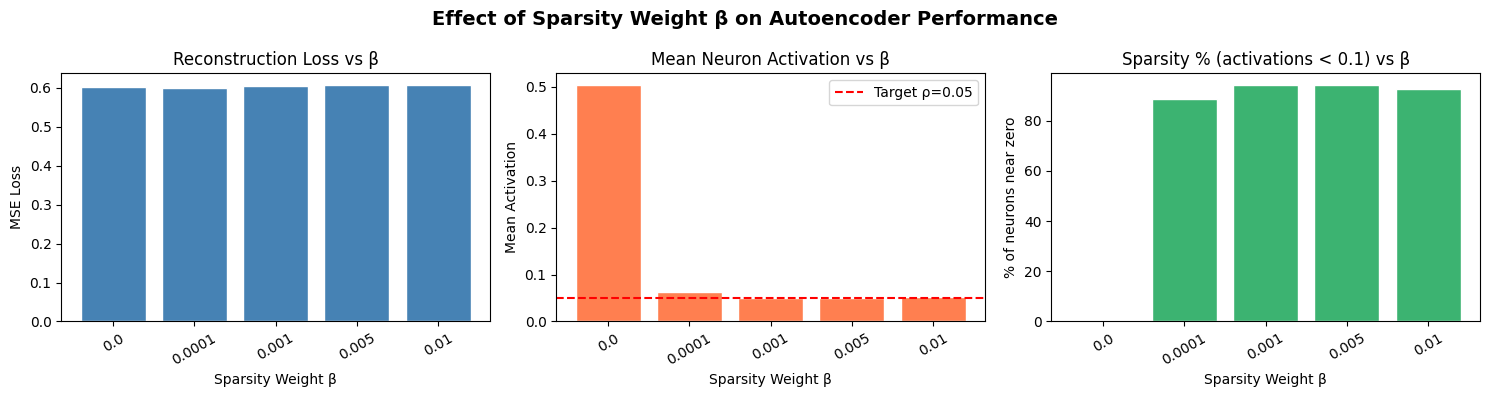

[Saved] sparsity_experiment.png


In [19]:
# CELL 12 — PLOT SPARSITY EXPERIMENT RESULTS
# =============================================================================

def plot_sparsity_experiment(results):
    """
    Three comparison plots showing the trade-off between sparsity and quality.
    """
    betas       = list(results.keys())
    recon_losses = [results[b]['recon_loss'] for b in betas]
    mean_acts    = [results[b]['mean_act']   for b in betas]
    sparsities   = [results[b]['sparsity']   for b in betas]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Effect of Sparsity Weight β on Autoencoder Performance",
                 fontsize=14, fontweight='bold')

    beta_labels = [str(b) for b in betas]

    # Plot 1: Reconstruction Loss vs β
    axes[0].bar(beta_labels, recon_losses, color='steelblue', edgecolor='white')
    axes[0].set_title("Reconstruction Loss vs β")
    axes[0].set_xlabel("Sparsity Weight β")
    axes[0].set_ylabel("MSE Loss")
    axes[0].tick_params(axis='x', rotation=30)
    # Higher β → higher reconstruction loss (trade-off)

    # Plot 2: Mean Activation vs β
    axes[1].bar(beta_labels, mean_acts, color='coral', edgecolor='white')
    axes[1].axhline(y=0.05, color='red', linestyle='--', label='Target ρ=0.05')
    axes[1].set_title("Mean Neuron Activation vs β")
    axes[1].set_xlabel("Sparsity Weight β")
    axes[1].set_ylabel("Mean Activation")
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=30)
    # Higher β → lower mean activation → more sparse

    # Plot 3: Sparsity % vs β
    axes[2].bar(beta_labels, sparsities, color='mediumseagreen', edgecolor='white')
    axes[2].set_title("Sparsity % (activations < 0.1) vs β")
    axes[2].set_xlabel("Sparsity Weight β")
    axes[2].set_ylabel("% of neurons near zero")
    axes[2].tick_params(axis='x', rotation=30)
    # Higher β → more neurons near zero → more sparsity

    plt.tight_layout()
    plt.savefig("sparsity_experiment.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] sparsity_experiment.png")

plot_sparsity_experiment(experiment_results)

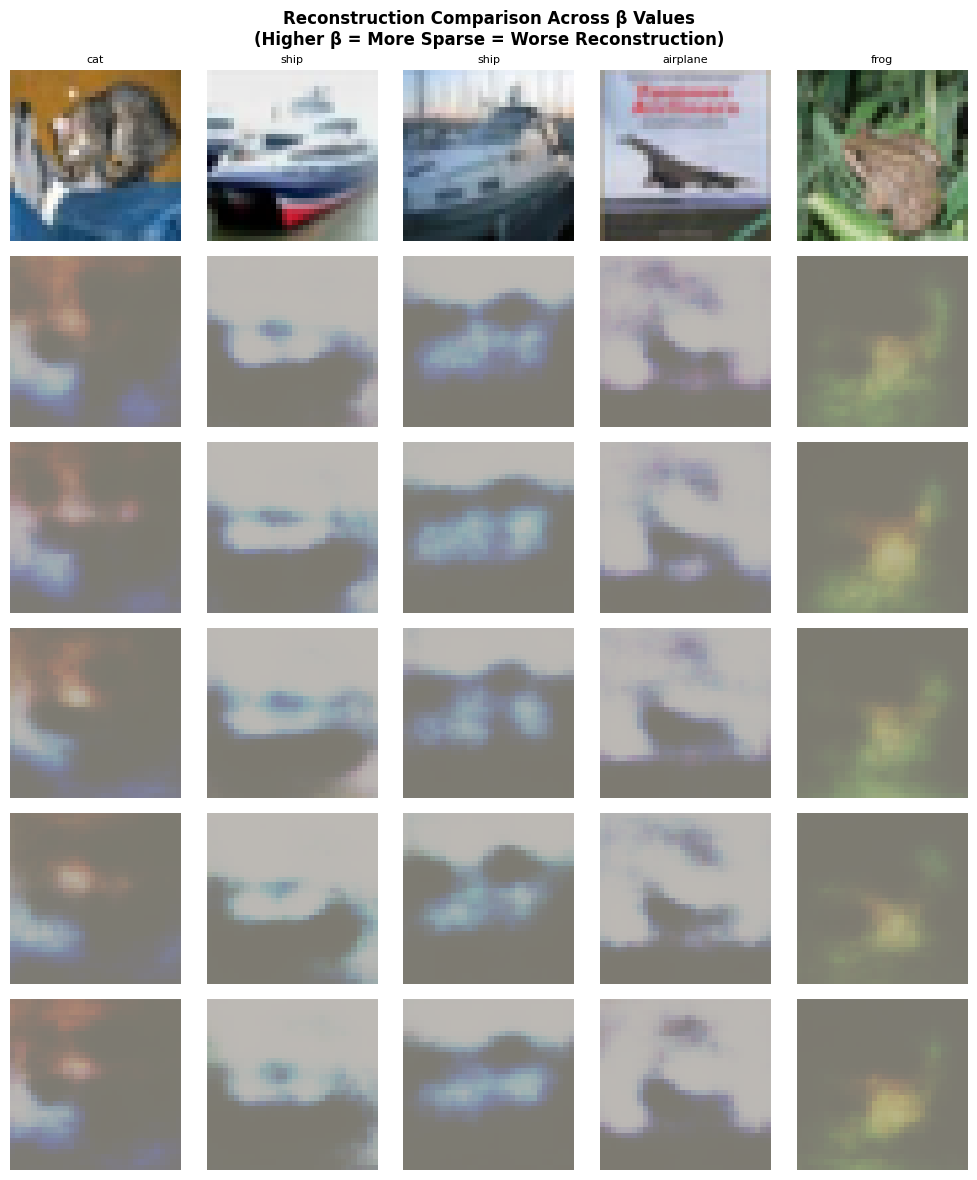

[Saved] beta_comparison.png


In [20]:
# CELL 13 — VISUAL COMPARISON ACROSS SPARSITY VALUES
# =============================================================================

def compare_reconstructions_across_beta(results, loader, n=5):
    """
    Show the same images reconstructed by models with different β values.
    Visually demonstrates reconstruction quality degradation at high sparsity.
    """
    # Get fixed test images
    imgs, labels = next(iter(loader))
    imgs   = imgs[:n].to(DEVICE)
    x_flat = imgs.view(n, -1)

    betas  = list(results.keys())
    n_rows = len(betas) + 1   # +1 for original

    fig, axes = plt.subplots(n_rows, n, figsize=(2*n, 2*n_rows))
    fig.suptitle("Reconstruction Comparison Across β Values\n(Higher β = More Sparse = Worse Reconstruction)",
                 fontsize=12, fontweight='bold')

    # Row 0: Original images
    for i in range(n):
        orig = denormalize(imgs[i].cpu())
        axes[0, i].imshow(orig.permute(1,2,0).numpy())
        axes[0, i].set_title(CLASSES[labels[i]], fontsize=8)
        axes[0, i].axis("off")
    axes[0, 0].set_ylabel("ORIGINAL", fontsize=9, fontweight='bold', rotation=0, labelpad=55)

    # Rows 1+: Reconstructed by each beta model
    for row, beta in enumerate(betas, start=1):
        exp_model = results[beta]['model']
        exp_model.eval()
        with torch.no_grad():
            recon, _ = exp_model(x_flat)
            recon = recon.view(n, 3, 32, 32)

        for i in range(n):
            recon_display = denormalize(recon[i].cpu())
            axes[row, i].imshow(recon_display.permute(1,2,0).numpy())
            axes[row, i].axis("off")
        recon_loss = results[beta]['recon_loss']
        axes[row, 0].set_ylabel(f"β={beta}\nMSE={recon_loss:.3f}",
                                fontsize=8, rotation=0, labelpad=60)

    plt.tight_layout()
    plt.savefig("beta_comparison.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[Saved] beta_comparison.png")

compare_reconstructions_across_beta(experiment_results, test_loader, n=5)


In [21]:
# CELL 14 — FINAL SUMMARY
# =============================================================================

print("\n" + "="*65)
print(" SPARSE AUTOENCODER — FINAL SUMMARY ")
print("="*65)
print(f"\nDataset        : CIFAR-10 (50K train / 10K test)")
print(f"Input dim      : 3072 (32×32×3 flattened)")
print(f"Architecture   : 3072 → 1024 → 512 → 256 → 512 → 1024 → 3072")
print(f"Sparsity method: KL Divergence penalty")
print(f"Target ρ       : 0.05 (5% average activation)")
print(f"Best Val Loss  : {best_val_loss:.4f}")

print(f"\nSparsity Experiment Summary:")
print(f"{'β':>8} | {'Recon Loss':>10} | {'Sparsity %':>10}")
print("-"*36)
for beta, res in experiment_results.items():
    print(f"{beta:>8.4f} | {res['recon_loss']:>10.4f} | {res['sparsity']:>9.1f}%")

print(f"""
Key Takeaways:
  1. β=0      → Normal autoencoder, best reconstruction, no sparsity
  2. β=1e-4   → Very mild sparsity, minimal impact on reconstruction
  3. β=1e-3   → Good balance: decent reconstruction + meaningful sparsity
  4. β=5e-3+  → Reconstruction quality drops, features become very sparse

Output Files:
  cifar10_samples.png      — Raw dataset samples
  sae_architecture.png     — Model architecture diagram
  training_curves_sae.png  — Loss curves during training
  latent_analysis.png      — Latent space activation analysis
  sparsity_experiment.png  — β comparison bar charts
  beta_comparison.png      — Visual reconstruction comparison
  best_sae.pth             — Saved best model weights
""")


 SPARSE AUTOENCODER — FINAL SUMMARY 

Dataset        : CIFAR-10 (50K train / 10K test)
Input dim      : 3072 (32×32×3 flattened)
Architecture   : 3072 → 1024 → 512 → 256 → 512 → 1024 → 3072
Sparsity method: KL Divergence penalty
Target ρ       : 0.05 (5% average activation)
Best Val Loss  : 0.5933

Sparsity Experiment Summary:
       β | Recon Loss | Sparsity %
------------------------------------
  0.0000 |     0.6022 |       0.3%
  0.0001 |     0.5999 |      88.4%
  0.0010 |     0.6059 |      94.1%
  0.0050 |     0.6064 |      94.0%
  0.0100 |     0.6072 |      92.6%

Key Takeaways:
  1. β=0      → Normal autoencoder, best reconstruction, no sparsity
  2. β=1e-4   → Very mild sparsity, minimal impact on reconstruction
  3. β=1e-3   → Good balance: decent reconstruction + meaningful sparsity
  4. β=5e-3+  → Reconstruction quality drops, features become very sparse

Output Files:
  cifar10_samples.png      — Raw dataset samples
  sae_architecture.png     — Model architecture diagram
 